In [1]:
import math
import collections
import dataclasses
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as pp

In [4]:
poll = pd.read_csv('poll.csv')
poll.head()

,vote
0,Brown
1,Green
2,Brown
3,Brown
4,Brown


In [5]:
# value_counts(normalize=True) counts how many times each vote appears,
# then normalize=True converts those counts to proportions (fractions of 1.0).
poll.value_counts(normalize=True)

vote 
Brown    0.511
Green    0.489
dtype: float64

In [6]:
# A simulated poll: draw 'nsample' random votes between Brown and Green.
# np.random.choice picks from ['Brown','Green'] with probabilities p=[brown, 1-brown],
# so 'brown' is the true underlying support level we're pretending to sample from.
def makepoll(nsample=1000, brown=0.51):
    return pd.DataFrame({'vote': np.random.choice(['Brown', 'Green'], nsample, p=[brown, 1.0 - brown])})

In [7]:
makepoll().value_counts(normalize=True)

vote 
Green    0.51
Brown    0.49
dtype: float64

In [8]:
makepoll().value_counts(normalize=True)

vote 
Brown    0.526
Green    0.474
dtype: float64

In [9]:
# Build a sampling DISTRIBUTION: run makepoll() 'ntries' times and record each
# poll's Brown/Green proportions. This bootstraps many hypothetical polls so we can
# see how much a single poll's result would naturally vary by chance.
def makedist(ntries=2000, nsample=1000, brown=0.51):
    return pd.DataFrame([makepoll(nsample, brown).value_counts(normalize=True) for i in range(ntries)])

In [10]:
counts = makedist()

In [11]:
counts

vote,Brown,Green
0,0.530,0.470
1,0.476,0.524
2,0.501,0.499
3,0.507,0.493
4,0.481,0.519
...,...,...
1995,0.505,0.495
1996,0.507,0.493
1997,0.524,0.476
1998,0.513,0.487


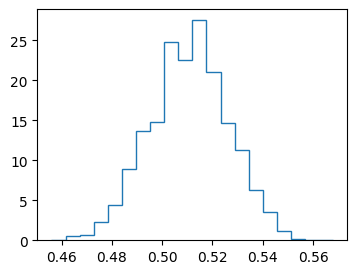

In [12]:
# Histogram of the Brown vote-share across all simulated polls.
# histtype='step' draws just the outline; density=True scales it to a probability
# density (area = 1) so distributions with different sample sizes are comparable.
pp.figure(figsize=(4,3))
pp.hist(counts['Brown'], histtype='step', bins=20, density=True);

In [13]:
counts.Brown.describe()

vote,Brown
count,2000.000000
mean,0.510485
std,0.015627
min,0.456000
25%,0.500000
50%,0.511000
75%,0.521000
max,0.568000


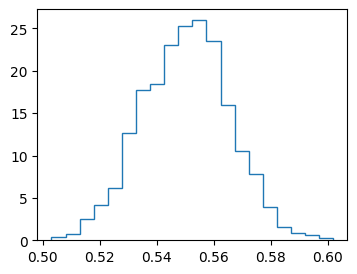

In [14]:
# Same distribution, but with true support brown=0.55 — shifts the whole curve right.
pp.figure(figsize=(4,3))
pp.hist(makedist(ntries=2000, nsample=1000, brown=0.55)['Brown'], histtype='step', bins=20, density=True);

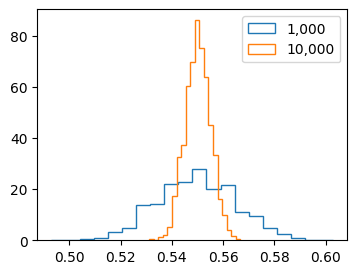

In [15]:
# Compare sample sizes: 1,000 vs 10,000 voters per poll.
# The larger sample produces a NARROWER curve — bigger polls = less random variation
# (the sampling distribution tightens around the true value).
pp.figure(figsize=(4,3))
pp.hist(makedist(ntries=2000, nsample=1000, brown=0.55)['Brown'], histtype='step', bins=20, density=True, label='1,000')
pp.hist(makedist(ntries=2000, nsample=10000, brown=0.55)['Brown'], histtype='step', bins=20, density=True, label='10,000')
pp.legend();

In [16]:
# .quantile(0.025) returns the 2.5th percentile of the Brown vote-share —
# the lower bound of a 95% confidence interval (2.5% in each tail = middle 95%).
makedist(ntries=2000, nsample=1000, brown=0.55)['Brown'].quantile(0.025)

vote 
Brown    0.517975
Name: 0.025, dtype: float64

In [19]:
# Lower 2.5% bound when true support is 0.54 — tests how low a poll could plausibly read.
makedist(ntries=2000, nsample=1000, brown=0.54)['Brown'].quantile(0.025)

vote 
Brown    0.509
Name: 0.025, dtype: float64

In [20]:
# .quantile(0.975) = the UPPER 97.5th-percentile bound when true support is only 0.47.
# Used to check: could a candidate at 47% still poll above 50% just by sampling luck?
makedist(ntries=2000, nsample=1000, brown=0.47)['Brown'].quantile(0.975)

vote 
Brown    0.5
Name: 0.975, dtype: float64